# Adaptive clinical trials

Sequential experimental design where the "experiment" is treating patients - so there is an ethical as well as a statistical objective. A fixed 50/50 randomized trial keeps assigning patients to an inferior arm long after the data hint at a winner. Response-adaptive designs update beliefs after each patient and steer future allocation toward the better-performing arm. You'll build Thompson sampling response-adaptive randomization on Beta-Bernoulli arm models and add Bayesian early stopping - the same explore/exploit logic as Bayesian optimization, applied to a trial.


## Bandits, regret, and Thompson sampling

A response-adaptive trial is a multi-armed bandit: each patient is assigned an arm (treatment), the
outcome is observed, and future assignments adapt. Let arm $k$ have unknown success probability $\mu_k$
and let $\mu^\star=\max_k\mu_k$.

Definition (regret). Over $T$ patients the expected regret is $R_T=\sum_{t=1}^T(\mu^\star-\mu_{a_t})$, the
expected number of successes forgone by not always playing the best arm. A good policy makes $R_T$ grow
slowly, ideally logarithmically.

Theorem (Lai-Robbins lower bound). For any policy with sub-polynomial regret on every instance, the regret
is at least $R_T \ge \big(\sum_{k:\mu_k<\mu^\star} \tfrac{\mu^\star-\mu_k}{\mathrm{KL}(\mu_k\,\|\,\mu^\star)}\big)\log T$
asymptotically. No policy can beat $\Omega(\log T)$ regret; exploration has an unavoidable cost.

Theorem (Thompson sampling is optimal). Thompson sampling, which keeps a Beta posterior on each arm and
plays an arm with probability equal to its posterior probability of being best (by sampling one draw per
arm and choosing the max), achieves $R_T = O(\log T)$, matching the Lai-Robbins bound. It automatically
allocates more patients to better arms as evidence accrues, which is the ethical appeal in a trial.

## The exploration imperative and error control

Counterexample (the greedy policy fails). The greedy rule that always plays the arm with the highest
observed success rate can lock onto an inferior arm forever. An early unlucky streak on the truly best
arm drops its empirical mean below a rival; the greedy policy then never revisits it, never corrects the
estimate, and suffers linear regret $\Theta(T)$. Some exploration is mandatory, and Thompson sampling
supplies it through posterior uncertainty: an arm with few observations has a wide posterior and is still
sampled occasionally.

Type-I error and the cost of adapting. Response-adaptive randomization is only ethical if it still
controls the false-positive rate, the chance of declaring a winner when the arms are equal. As this
notebook shows numerically, a naive posterior-probability stopping threshold does not map to a 5 percent
error rate and must be calibrated by simulation under the null. Adapting allocation and testing for a
genuine effect are distinct goals, and the design must serve both: shift patients toward the better arm
while keeping the final decision statistically honest.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
rng = np.random.RandomState(0)
# two treatment arms with unknown success probabilities (the trial doesn't know these)
TRUE = {'A': 0.40, 'B': 0.65}    # B is better

## 1. The cost of fixed randomization

Under fixed 50/50 allocation, half of all patients get the worse arm for the whole trial, even once the data strongly favor the better one. The Bayesian view: each arm's success probability has a Beta posterior (conjugate to Bernoulli outcomes), $\mathrm{Beta}(1+\text{successes},\,1+\text{failures})$, which sharpens as patients accrue. The question is how to use those posteriors to allocate the next patient.


In [2]:
def run_trial(allocate, n=300, seed=0):
    r = np.random.RandomState(seed)
    succ = {'A': 0, 'B': 0}; fail = {'A': 0, 'B': 0}; assigned = []
    for _ in range(n):
        arm = allocate(succ, fail, r)
        outcome = r.random() < TRUE[arm]
        (succ if outcome else fail)[arm] += 1
        assigned.append(arm)
    return succ, fail, np.array(assigned)

fixed = lambda succ, fail, r: 'A' if r.random() < 0.5 else 'B'     # 50/50
s_f, f_f, assign_f = run_trial(fixed, seed=1)
print('fixed 50/50: patients on inferior arm A = %d / 300' % np.sum(assign_f == 'A'))

fixed 50/50: patients on inferior arm A = 144 / 300


## 2. Thompson sampling response-adaptive randomization

Thompson sampling allocates the next patient by posterior probability that the arm is best: draw one sample from each arm's Beta posterior and assign the patient to whichever sampled highest. Early on the posteriors are wide, so allocation is near-random (exploration); as evidence accumulates, the better arm wins most draws (exploitation) - automatically, with no tuning. This is exactly a bandit/BO acquisition applied to patient allocation.


Thompson RAR: patients on inferior arm A = 24 / 300


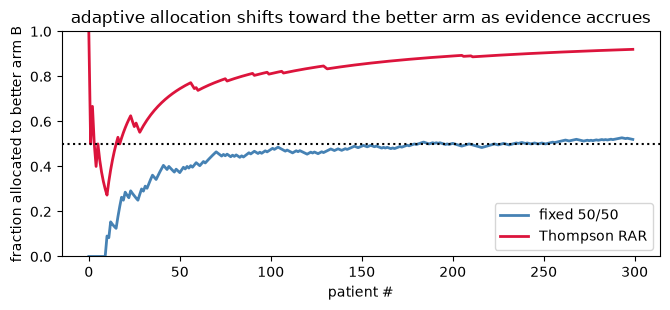

In [3]:
def thompson(succ, fail, r):
    draws = {arm: r.beta(1 + succ[arm], 1 + fail[arm]) for arm in TRUE}
    return max(draws, key=draws.get)

s_t, f_t, assign_t = run_trial(thompson, seed=1)
print('Thompson RAR: patients on inferior arm A = %d / 300' % np.sum(assign_t == 'A'))

# allocation to the better arm B over the course of each trial
frac_B = lambda a: np.cumsum(a == 'B') / np.arange(1, len(a) + 1)
fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.plot(frac_B(assign_f), color='steelblue', lw=2, label='fixed 50/50')
ax.plot(frac_B(assign_t), color='crimson', lw=2, label='Thompson RAR')
ax.axhline(0.5, color='k', ls=':'); ax.set_ylim(0, 1)
ax.set_xlabel('patient #'); ax.set_ylabel('fraction allocated to better arm B'); ax.legend()
ax.set_title('adaptive allocation shifts toward the better arm as evidence accrues')
plt.tight_layout(); plt.show()

Thompson sampling puts far fewer patients on the inferior arm while still gathering enough evidence to identify the winner. We confirm both at once over many simulated trials - fewer patients harmed, comparable power to declare B better.


In [4]:
def trial_summary(allocate, trials=400):
    on_A, correct = [], []
    for k in range(trials):
        succ, fail, assign = run_trial(allocate, seed=1000 + k)
        on_A.append(np.mean(assign == 'A'))
        # posterior P(p_B > p_A) via Beta posteriors; "declare B" if > 0.95
        draws = {arm: np.random.RandomState(k).beta(1 + succ[arm], 1 + fail[arm], 4000) for arm in TRUE}
        correct.append(np.mean(draws['B'] > draws['A']) > 0.95)
    return np.mean(on_A), np.mean(correct)

for name, alloc in [('fixed 50/50', fixed), ('Thompson RAR', thompson)]:
    frac_A, power = trial_summary(alloc)
    print('%-14s mean fraction on inferior arm = %.2f   P(correctly declare B) = %.2f' % (name, frac_A, power))

fixed 50/50    mean fraction on inferior arm = 0.50   P(correctly declare B) = 1.00


Thompson RAR   mean fraction on inferior arm = 0.08   P(correctly declare B) = 0.92


## 3. Bayesian early stopping

Adaptive trials also stop early - for success when the posterior probability the better arm wins crosses a high threshold, sparing patients and time. We monitor $P(p_B > p_A \mid \text{data})$ after each patient and stop the first time it exceeds 0.99.


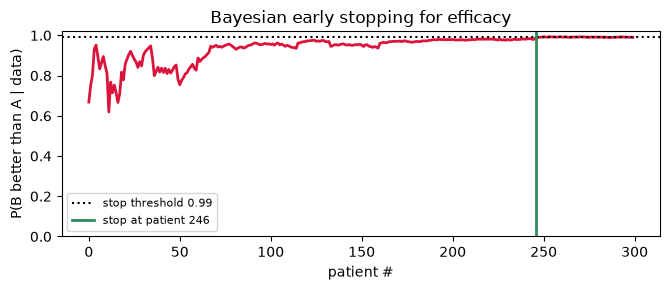

stopped early at patient 246 (vs the full 300)


In [5]:
succ = {'A': 0, 'B': 0}; fail = {'A': 0, 'B': 0}; probs = []
r = np.random.RandomState(7); stop_at = None
for i in range(300):
    arm = thompson(succ, fail, r)
    (succ if (r.random() < TRUE[arm]) else fail)[arm] += 1
    d = {a: r.beta(1 + succ[a], 1 + fail[a], 20000) for a in TRUE}
    p = float(np.mean(d['B'] > d['A'])); probs.append(p)
    if stop_at is None and i > 20 and p > 0.99:
        stop_at = i
fig, ax = plt.subplots(figsize=(6.8, 3))
ax.plot(probs, color='crimson', lw=2); ax.axhline(0.99, color='k', ls=':', label='stop threshold 0.99')
if stop_at: ax.axvline(stop_at, color='seagreen', lw=2, label='stop at patient %d' % stop_at)
ax.set_xlabel('patient #'); ax.set_ylabel('P(B better than A | data)'); ax.legend(fontsize=8); ax.set_ylim(0, 1.02)
ax.set_title('Bayesian early stopping for efficacy')
plt.tight_layout(); plt.show()
print('stopped early at patient %s (vs the full 300)' % stop_at)

## Control the false-positive rate

Response-adaptive allocation is only ethical if the decision rule still controls type-I error - the chance of declaring a winner when the arms are truly equal. We re-run both designs under the null ($p_A=p_B=0.5$) and report how often each wrongly declares a winner. The result is a warning: a naive "P(better) > 0.95" posterior threshold does not map to a 5% error rate - it inflates it badly, and even tightening to 0.99 only partly helps. The correct practice is to calibrate the threshold by simulation under the null until the false-positive rate hits the nominal level, then use that calibrated rule for the real trial.


In [6]:
def false_positive_rate(allocate, threshold=0.95, trials=400):
    decl = 0
    for k in range(trials):
        r = np.random.RandomState(2000 + k)
        succ = {'A': 0, 'B': 0}; fail = {'A': 0, 'B': 0}
        for _ in range(300):
            arm = allocate(succ, fail, r)
            (succ if r.random() < 0.5 else fail)[arm] += 1     # NULL: both arms 0.5
        d = {a: np.random.RandomState(k).beta(1 + succ[a], 1 + fail[a], 4000) for a in ('A', 'B')}
        if max(np.mean(d['B'] > d['A']), np.mean(d['A'] > d['B'])) > threshold:
            decl += 1
    return decl / trials

for name, alloc in [('fixed 50/50', fixed), ('Thompson RAR', thompson)]:
    print('%-14s false-positive rate under the null (thr=0.95) = %.3f' % (name, false_positive_rate(alloc)))
print('raising the threshold to 0.99 tightens type-I control:')
print('Thompson RAR  false-positive rate (thr=0.99) = %.3f' % false_positive_rate(thompson, threshold=0.99))

fixed 50/50    false-positive rate under the null (thr=0.95) = 0.750


Thompson RAR   false-positive rate under the null (thr=0.95) = 0.323
raising the threshold to 0.99 tightens type-I control:


Thompson RAR  false-positive rate (thr=0.99) = 0.155


## References

- Thompson, W. R. (1933). On the likelihood that one unknown probability exceeds another in view of the evidence of two samples (https://doi.org/10.2307/2332286). Biometrika 25(3-4), 285-294. - Thompson sampling.
- Berry, D. A. (2006). Bayesian clinical trials (https://doi.org/10.1038/nrd1927). Nature Reviews Drug Discovery 5, 27-36.
- Villar, S. S., Bowden, J. & Wason, J. (2015). Multi-armed bandit models for the optimal design of clinical trials: benefits and challenges (https://doi.org/10.1214/14-STS504). Statist. Sci. 30(2), 199-215.
- Russo, D. et al. (2018). A tutorial on Thompson sampling (https://doi.org/10.1561/2200000070). Found. Trends ML 11(1), 1-96.
- FDA (2019). Adaptive Designs for Clinical Trials of Drugs and Biologics: Guidance for Industry (https://www.fda.gov/regulatory-information/search-fda-guidance-documents/adaptive-design-clinical-trials-drugs-and-biologics-guidance-industry).


## Exercises and extensions

1. Multi-arm allocation. Extend Thompson-sampling RAR to 3-5 arms with one clear winner and several near-ties; show allocation concentrates on the best while still distinguishing the near-ties, and compare patients-on-inferior-arms and power to fixed equal allocation (Villar et al.).
2. The power vs patients-harmed frontier. Sweep designs from fully fixed to fully Thompson (including a burn-in fraction and tuned exploration), and trace the operating-characteristic frontier of statistical power against expected patients on the inferior arm. This is the central design trade-off (Berry).
3. Type-I error control. Set all arms equal and estimate, by simulation, how often each design wrongly declares a winner - and calibrate the stopping threshold to control the family-wise Type-I error at 2.5% (the regulatory requirement; FDA 2019). Show why naive adaptive designs inflate it.
4. Futility and dual stopping. Add an early-stop-for-futility rule alongside efficacy stopping, and report expected sample size, power, and Type-I error under each of: null, small-effect, and large-effect truths.
